# **XGBoost**

## **Librerías**

In [120]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [121]:
from sklearn.metrics import *
from sklearn.ensemble import *
from sklearn.pipeline import *
from xgboost import XGBClassifier
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.feature_selection import *

## **Data**

In [122]:
df = pd.read_excel("../data/processed/df_to_model_frenel_15102025.xlsx")
df.head()

,target_tfg,pais_encuesta,grupo_origen,pais_nacimiento,edad,genero,grupo_etnico,nivel_escolaridad,regimen_salud,ocupacion,...,hacinamiento_hogar,hogar_migrantes,grupo_origen_ingles,ocupacion_agricola,imc,clasificacion_imc,grupo_edad,clasificacion_tfg,clasificacion_pa,creatinina_elevada
0,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,49,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,32.326531,Obesidad,41-50,Ligera (60-89),Hipertensión grado 2 (moderada),False
1,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,83,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador privado,Desempleado,...,NO,NO,AFRODESCENDANT,NO,22.206331,Normal,60+,Leve Moderada (45-59),Normal-alta,True
2,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,70,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador público,Comerciante,...,SI,NO,AFRODESCENDANT,NO,20.820940,Normal,60+,Ligera (60-89),Hipertensión grado 2 (moderada),False
3,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,25,Femenino,AFRODESCENDIENTE,Técnica,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,23.738662,Normal,18-30,Ligera (60-89),Normal,True
4,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,64,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Desempleado,...,NO,NO,AFRODESCENDANT,NO,19.257029,Normal,60+,Leve Moderada (45-59),Normal,True


## **Preprocesamiento**

### **Selección de Variables**

In [123]:
data_modelo = df.drop(columns=['pais_encuesta', 'pais_nacimiento', 'ocupacion', 'georeferenciacion', 'grupo_origen_ingles', 'tasa_filtracion_glomerular'])
data_modelo_numericas= data_modelo.drop(columns = ['clasificacion_imc', 'grupo_edad', 'clasificacion_tfg', 'clasificacion_pa', 'creatinina_elevada', 'creatinina', 'grupo_origen',
                                                   'diabetes_durante_embarazo'])
data_modelo_categoricas = data_modelo.drop(columns = ['peso', 'grupo_edad', 'talla', 'presion_arterial_sistolica', 'presion_arterial_diastolica', 'creatinina', 'imc'])

### **Codificación Variables Categóricas**

In [124]:
cat_cols = data_modelo_numericas.select_dtypes(include=['object']).columns
num_cols = data_modelo_numericas.select_dtypes(include=['int64', 'float64']).columns
print("Categóricas:", len(cat_cols))
print("Numéricas:", len(num_cols))

Categóricas: 36
Numéricas: 7


In [125]:
df_encoded = pd.get_dummies(data_modelo_numericas, columns=cat_cols, drop_first=True)

## **Modelos**

### **Conjuntos de `Train` y `Test`**

In [126]:
X = df_encoded.drop('target_tfg', axis=1)
y = df_encoded['target_tfg']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [127]:
print(f' X_train.shape: {X_train.shape}\n X_test.shape: {X_test.shape}\n y_train.shape: {y_train.shape}\n y_test.shape: {y_test.shape}')

 X_train.shape: (3567, 60)
 X_test.shape: (1189, 60)
 y_train.shape: (3567,)
 y_test.shape: (1189,)


### **Modelo 1: Recall**

#### **Implementación Modelo**

In [128]:
# Calcular ratio para scale_pos_weight = (N_negativos / N_positivos)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(objective='binary:logistic',eval_metric='logloss', scale_pos_weight=ratio,  # ¡MUY IMPORTANTE para desbalance!
    random_state=11,use_label_encoder=False)

In [129]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'gamma': [0, 1]
}


In [130]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=make_scorer(recall_score),  # Optimiza detección de la clase 1
    cv=5,   # Estratifica automáticamente al ser clasificación
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 1.0], 'gamma': [0, 1], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], ...}"
,scoring,make_scorer(r...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


#### **Métricas y Resultados**

In [131]:
best_xgb = grid_xgb.best_estimator_
print("Mejores Hiperparámetros:", grid_xgb.best_params_)
print("Mejor Recall (CV):", grid_xgb.best_score_)

# Predicciones en train y test
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)


print("\n RECALL en Train:", recall_score(y_train, y_train_pred))
print("\n RECALL en Test:", recall_score(y_test, y_test_pred))

print("\nReporte en Test:")
print(classification_report(y_test, y_test_pred))


Mejores Hiperparámetros: {'colsample_bytree': 0.7, 'gamma': 1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Mejor Recall (CV): 0.6438044614848379

 RECALL en Train: 0.7084432717678101

 RECALL en Test: 0.6996047430830039

Reporte en Test:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       936
           1       0.39      0.70      0.50       253

    accuracy                           0.70      1189
   macro avg       0.64      0.70      0.64      1189
weighted avg       0.79      0.70      0.73      1189



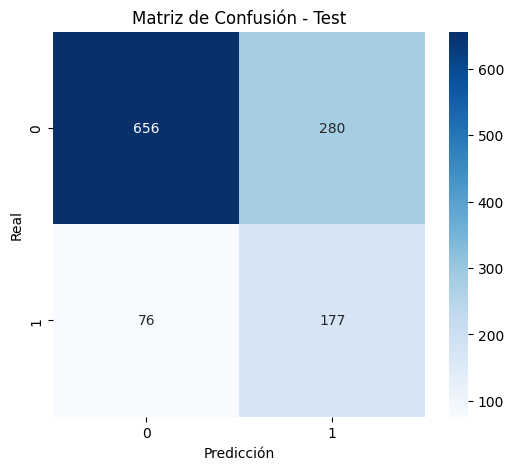

In [132]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Paleta azul
plt.title("Matriz de Confusión - Test")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


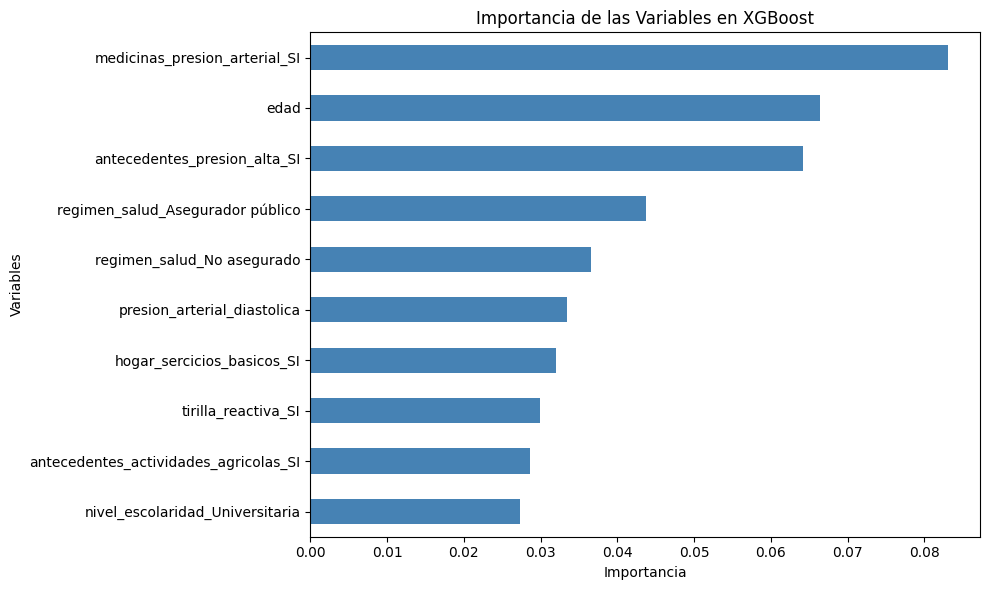

In [133]:
best_xgb = grid_xgb.best_estimator_
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)
top_n = 10
plt.figure(figsize=(10, 6))
importances.tail(top_n).plot(kind='barh', color='steelblue')
plt.title('Importancia de las Variables en XGBoost')
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

### **Modelo 2: F1-Score**

#### **Implementación Modelo**

In [134]:
# Calcular ratio para scale_pos_weight = (N_negativos / N_positivos)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(objective='binary:logistic',eval_metric='logloss', scale_pos_weight=ratio,  # ¡MUY IMPORTANTE para desbalance!
    random_state=11,use_label_encoder=False)

In [135]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'gamma': [0, 1]
}


In [136]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=make_scorer(f1_score),  # Optimiza detección de la clase 1
    cv=5,   # Estratifica automáticamente al ser clasificación
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 1.0], 'gamma': [0, 1], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], ...}"
,scoring,make_scorer(f...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


#### **Métricas y Resultados**

In [137]:
best_xgb = grid_xgb.best_estimator_
print("Mejores Hiperparámetros:", grid_xgb.best_params_)
print("Mejor Recall (CV):", grid_xgb.best_score_)

# Predicciones en train y test
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)


print("\n RECALL en Train:", recall_score(y_train, y_train_pred))
print("\n RECALL en Test:", recall_score(y_test, y_test_pred))

print("\nReporte en Test:")
print(classification_report(y_test, y_test_pred))


Mejores Hiperparámetros: {'colsample_bytree': 0.7, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Mejor Recall (CV): 0.48363123576356515

 RECALL en Train: 0.8509234828496042

 RECALL en Test: 0.6521739130434783

Reporte en Test:
              precision    recall  f1-score   support

           0       0.89      0.75      0.81       936
           1       0.41      0.65      0.51       253

    accuracy                           0.73      1189
   macro avg       0.65      0.70      0.66      1189
weighted avg       0.79      0.73      0.75      1189



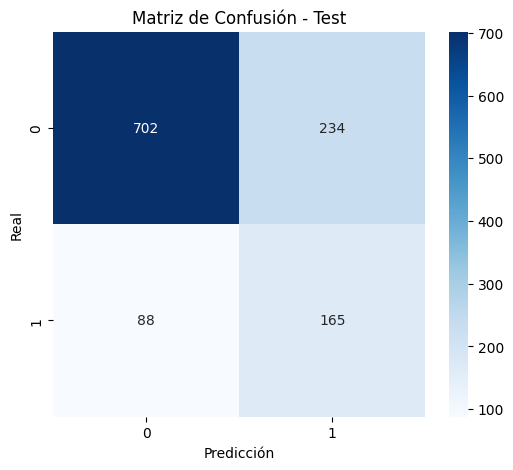

In [138]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Paleta azul
plt.title("Matriz de Confusión - Test")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()
